# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from tqdm.auto import tqdm
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from pathlib import Path

# 2. Upload File

In [2]:
DATA_FILE = 'fcc_news_release_metadata_with_body_text.parquet'

df = pd.read_parquet(DATA_FILE)

In [3]:
OUTPUT_DIR = Path('outputs')
TABLE_DIR = OUTPUT_DIR / 'tables'
FIGURE_DIR = OUTPUT_DIR / 'figures'

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# 3. Exploratory Data Analysis

## 3.1. Data Quality Checks

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3139 entries, 0 to 3138
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   page_title         3139 non-null   object        
 1   full_title         3139 non-null   object        
 2   document_type      3139 non-null   object        
 3   bureaus            3139 non-null   object        
 4   description        1567 non-null   object        
 5   webpage_url        3139 non-null   object        
 6   selected_txt_urls  3139 non-null   object        
 7   all_txt_urls       3139 non-null   object        
 8   all_txt_count      3139 non-null   int64         
 9   released_on        3139 non-null   datetime64[ns]
 10  issued_on          3139 non-null   datetime64[ns]
 11  adopted            806 non-null    datetime64[ns]
 12  filename           3139 non-null   object        
 13  body_text          3139 non-null   object        
 14  body_wor

In [5]:
# Use released_on as the main document date.
df['date'] = df['released_on'].fillna(df['issued_on'])
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['year'] = df['date'].dt.year
df['quarter'] = df['date'].dt.to_period('Q').astype(str)
df['month'] = df['date'].dt.to_period('M').astype(str)

In [6]:
# Keep documents from year 2010 to 2025
df = df[df['year'].between(2010, 2025)]

In [7]:
qc_summary_dict = {
    'number_of_rows': df.shape[0],
    'number_of_columns': df.shape[1],
    'missing_body_text': df['body_text'].isna().sum(),
    'zero_body_word_count': (df['body_word_count'] == 0).sum(),
    'duplicate_filenames': df['filename'].duplicated().sum(),
    "body_word_count_mean": round(df["body_word_count"].mean()),
    "body_word_count_median": int(df["body_word_count"].median()),
    'min_data': df['date'].min(),
    'max_date': df['date'].max()
}

qc_summary = pd.DataFrame(
    qc_summary_dict.items(),
    columns=['metric', 'value']
)

qc_summary

,metric,value
0,number_of_rows,3073
1,number_of_columns,21
2,missing_body_text,0
3,zero_body_word_count,0
4,duplicate_filenames,0
5,body_word_count_mean,422
6,body_word_count_median,350
7,min_data,2010-01-05 00:00:00
8,max_date,2025-12-23 00:00:00


In [8]:
df['extraction_method'].value_counts(dropna=False).rename('count').to_frame()

,count
extraction_method,
dateline,2126
city_prefix_without_date,800
content_after_front_matter,146
letter_salutation,1


In [9]:
df['footer_method'].value_counts(dropna=False).rename('count').to_frame()

,count
footer_method,
footer_marker,2959
no_footer_marker,93
commissioner_office_footer,17
trailing_media_contact,2
office_media_footer,1
inline_footer_marker,1


## 3.2. Explore Date Variables

In [10]:
def plot_doc_trend(summary_df, x_label, y_label, tick_every=None):

    cols = summary_df.columns
    period = cols[0]
    var = cols[1]
    num_of_rows = len(summary_df)

    x_pos = range(num_of_rows)

    if tick_every == None:
        tick_every = max(1, num_of_rows // 12)
    
    plt.figure(figsize=(10, 5))
    plt.plot(x_pos, summary_df[var])
    
    plt.title(f'{y_label} by {x_label}')
    plt.xlabel(x_label)
    plt.ylabel(y_label)

    tick_positions = list(range(0, num_of_rows, tick_every))
    
    plt.xticks(
        tick_positions,
        summary_df[period].astype(str).iloc[tick_positions],
        rotation=45,
        ha='right'
    )
    
    plt.tight_layout()
    plt.show()

In [11]:
word_stats_by_year = (
    df.groupby('year')['body_word_count']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reset_index()
)

word_stats_by_year

,year,count,mean,median,min,max
0,2010,223,402.511211,344.0,39,2600
1,2011,161,466.180124,376.0,99,2811
2,2012,142,451.978873,387.0,69,1528
3,2013,134,445.276119,393.5,69,4072
4,2014,144,375.020833,343.0,86,1317
5,2015,141,406.319149,366.0,71,2229
6,2016,112,393.383929,370.0,49,899
7,2017,183,349.508197,307.0,48,2242
8,2018,192,374.531250,320.0,25,1452
9,2019,214,404.280374,353.0,126,1992


In [12]:
doc_by_year = df.groupby('year').size().rename('n_documents').reset_index()
doc_by_quarter = df.groupby('quarter').size().rename('n_documents').reset_index()
doc_by_month = df.groupby('month').size().rename('n_documents').reset_index()

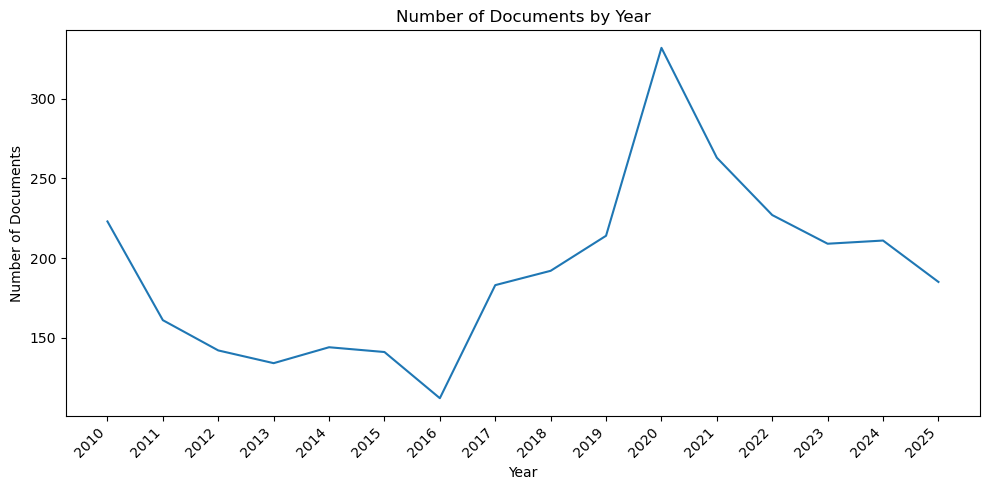

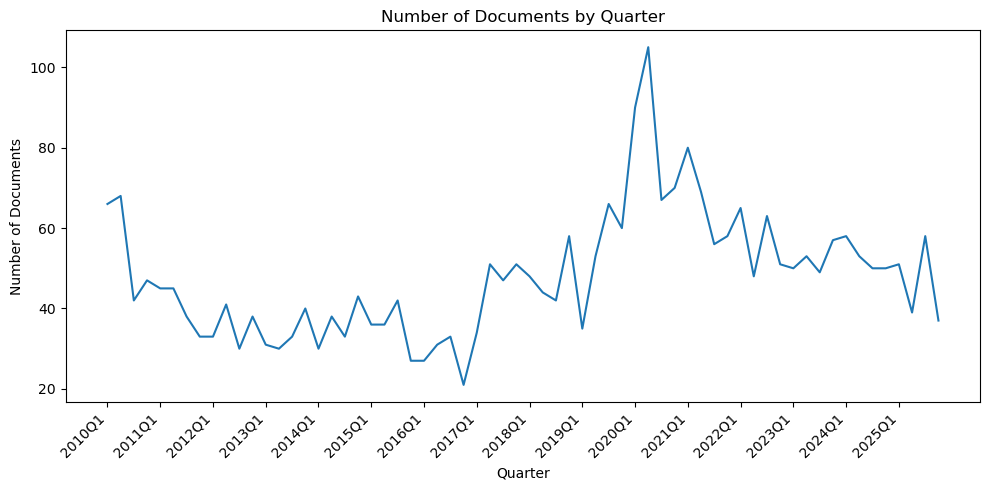

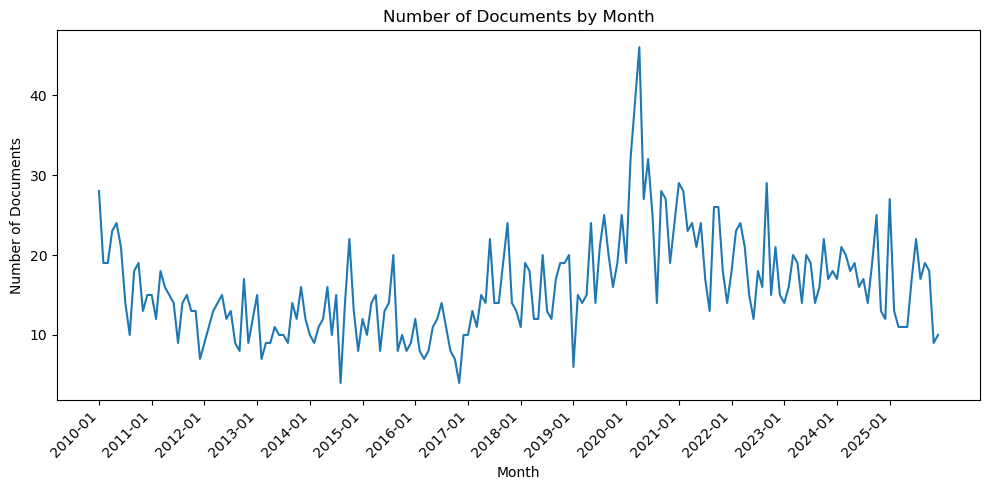

In [13]:
plot_doc_trend(doc_by_year, 'Year', 'Number of Documents', 1)
plot_doc_trend(doc_by_quarter, 'Quarter', 'Number of Documents', 4)
plot_doc_trend(doc_by_month, 'Month', 'Number of Documents', 12)

In [14]:
avg_words_by_year = df.groupby('year')['body_word_count'].mean().rename('avg_words_per_document').reset_index()
avg_words_by_quarter = df.groupby('quarter')['body_word_count'].mean().rename('avg_words_per_document').reset_index()
avg_words_by_month = df.groupby('month')['body_word_count'].mean().rename('avg_words_per_document').reset_index()

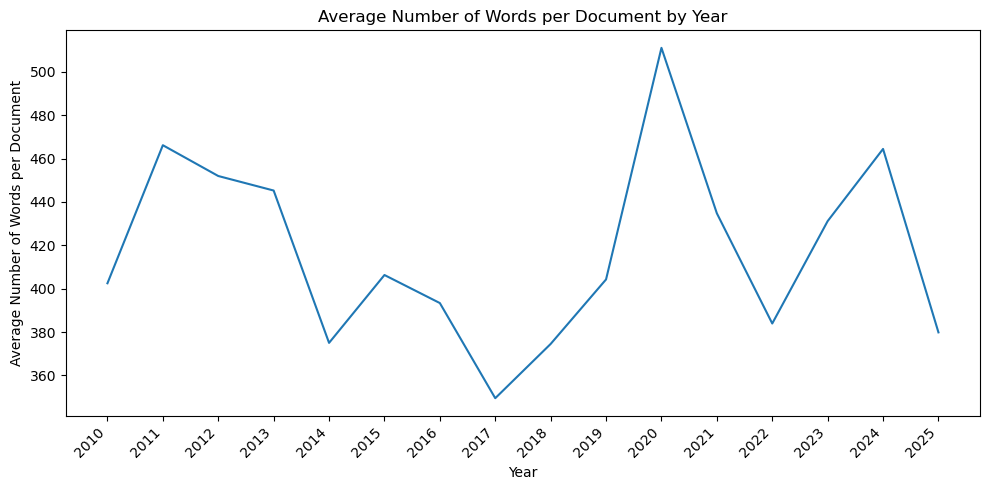

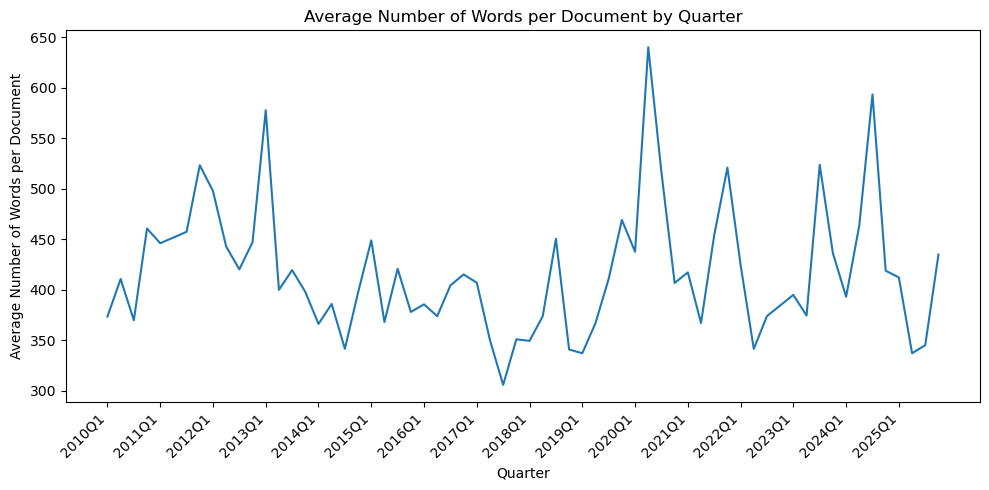

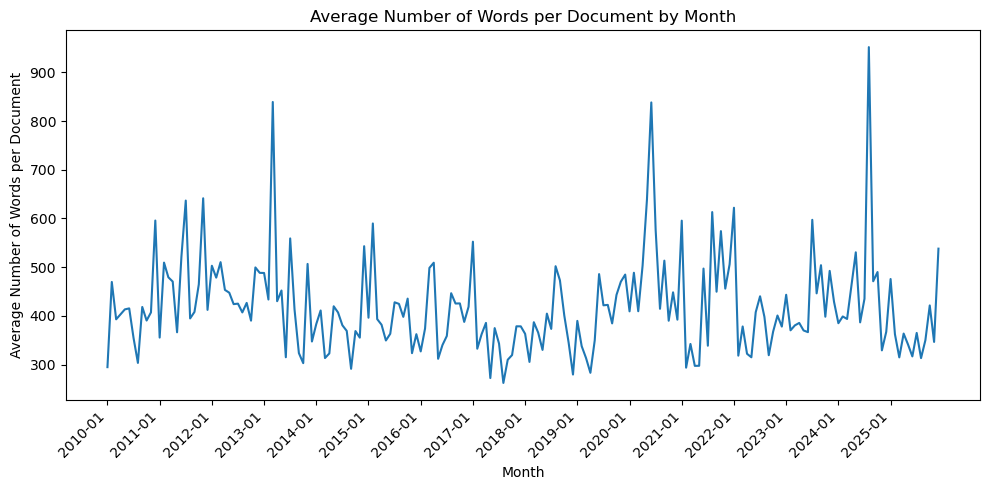

In [15]:
plot_doc_trend(avg_words_by_year, 'Year', 'Average Number of Words per Document', 1)
plot_doc_trend(avg_words_by_quarter, 'Quarter', 'Average Number of Words per Document', 4)
plot_doc_trend(avg_words_by_month, 'Month', 'Average Number of Words per Document', 12)

# 4. Text Preprocessing

## 4.1. Policy Dictionary and Technical-Term


### 4.1.1. Helper Functions

In [16]:
def clean_word(word):
    """
    Normalize a word
    """
    word = str(word).lower().strip()
    word = re.sub(r'[^a-z0-9_-]', '', word)
    return word

In [17]:
def normalize_technical_phrases(text):
    """
    Normalize important telecommunications phrases before spaCy tokenization.
    """
    if pd.isna(text):
        return ''

    text = str(text)

    for pattern, replacement in technical_phrase_patterns:
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)

    return text

In [18]:
def make_technical_terms(policy_dictionary):
    terms = set(manual_technical_terms)

    for _, replacement in technical_phrase_patterns:
        cleaned_replacement = clean_word(replacement)
        if cleaned_replacement:
            terms.add(cleaned_replacement)

    for dictionary_terms in policy_dictionary.values():
        for term in dictionary_terms:
            normalized_term = normalize_technical_phrases(term)
            for piece in re.findall(r"[A-Za-z0-9_/-]+", normalized_term):
                cleaned_piece = clean_word(piece)
                if not cleaned_piece:
                    continue

                is_technical_like = (
                    cleaned_piece in manual_technical_terms
                    or "_" in cleaned_piece
                    or any(char.isdigit() for char in cleaned_piece)
                    or (piece.isupper() and len(cleaned_piece) <= 8)
                )

                if is_technical_like and cleaned_piece not in STOP_WORDS:
                    terms.add(cleaned_piece)

    return terms

### 4.1.2. Setup Dictionary and Terms

In [19]:
policy_dictionary = {
    'accessibility': [
        'accessibility', 'accessibility clearinghouse', 'accessible emergency information',
        'american sign language', 'asl', 'audible crawl', 'audio description', 'captioning',
        'closed captioning', 'closed captioning display settings',
        'communications and video accessibility act', 'cvaa', 'disabilities', 'disability',
        'disability advisory committee', 'hearing aid compatibility', 'hearing aid compatible',
        'internet protocol captioned telephone service', 'ip cts', 'ip relay',
        'people with disabilities', 'real time text', 'real-time text', 'relay service', 'rtt',
        'telecommunications relay service', 'trs', 'tty', 'video description',
        'video relay service', 'video relay services', 'vrs',
    ],
    'broadband': [
        'bdc', 'bead', 'broadband', 'broadband access', 'broadband data collection',
        'broadband deployment', 'broadband equity access and deployment', 'broadband internet',
        'broadband map', 'broadband mapping', 'broadband maps', 'broadband providers',
        'broadband service', 'broadband services', 'digital discrimination', 'digital divide',
        'digital equity', 'digital inclusion', 'high speed internet', 'internet access',
        'internet service', 'national broadband map', 'national broadband plan', 'rural areas',
        'rural broadband', 'tribal communities', 'tribal lands', 'tribal priority window',
    ],
    'compliance': [
        'apparent liability', 'citation', 'citation and order', 'civil penalty', 'compliance',
        'compliance plan', 'consent decree', 'enforcement', 'enforcement action',
        'field office', 'fine', 'fines', 'forfeiture', 'forfeiture order', 'fraud abuse',
        'investigation', 'investigations', 'nal', 'notice of apparent liability', 'penalty',
        'pirate act', 'pirate radio', 'preventing illegal radio abuse through enforcement act',
        'settlement', 'settlement agreement', 'unauthorized operation', 'violation',
        'violations', 'waste fraud abuse', 'waste fraud and abuse',
    ],
    'competition': [
        'acquisition', 'antitrust', 'broadband competition', 'business data services',
        'common carrier', 'competition', 'competitive', 'competitive bidding',
        'competitiveness', 'deregulation', 'deregulatory initiative', 'forbearance',
        'intercarrier compensation', 'interconnection', 'market power', 'merger',
        'merger review', 'net neutrality', 'north american numbering council',
        'number portability', 'numbering plan', 'numbering resources', 'obsolete rules',
        'open internet', 'open internet rules', 'outdated rules', 'paperwork reduction',
        'pole attachment', 'pole attachments', 'regulatory burdens', 'regulatory reform',
        'repeal', 'special access', 'technology transition', 'technology transitions',
        'toll free numbering', 'video marketplace', 'wireline competition',
    ],
    'media_broadcasting': [
        'am radio', 'am revitalization', 'atsc', 'atsc 3.0', 'broadcast', 'broadcast internet',
        'broadcast ownership', 'broadcast station', 'broadcast stations',
        'broadcast television', 'broadcaster', 'broadcasters', 'broadcasting', 'cable',
        'cable operator', 'cable operators', 'dbs', 'digital television',
        'direct broadcast satellite', 'dtv', 'eeo', 'equal employment opportunity',
        'fm booster', 'fm boosters', 'fm radio', 'fm translator', 'foreign sponsorship',
        'foreign sponsorship identification', 'local journalism', 'low power fm',
        'low power television', 'lpfm', 'lptv', 'media ownership',
        'multichannel video programming distributor', 'mvpd', 'next gen tv', 'nextgen tv',
        'quadrennial review', 'radio', 'radio station', 'retransmission consent', 'television',
        'television station', 'video programming', 'video programming distributor',
    ],
    'national_security': [
        'bgp', 'bgp routing', 'border gateway protocol', 'cable landing',
        'cable landing license', 'china mobile', 'china telecom', 'china unicom',
        'communications equipment', 'comnet', 'covered communications equipment',
        'covered equipment', 'covered list', 'covered list entities', 'cyber',
        'cyber security', 'cyber trust mark', 'cybersecurity',
        'cybersecurity labeling program', 'dahua', 'dji', 'equipment authorization',
        'equipment authorization process', 'equipment authorization program',
        'equipment authorization rules', 'foreign adversaries', 'foreign adversary',
        'foreign ownership', 'foreign ownership review', 'hikvision', 'huawei',
        'international section 214', 'iot labeling', 'iot labeling program', 'kaspersky',
        'national security', 'national security threat', 'network equipment',
        'pacific networks', 'rip and replace', 'section 214', 'section 214 authority',
        'section 214 authorization', 'section 214 authorizations',
        'secure and trusted communications networks', 'secure by design',
        'secure equipment act', 'secure networks act', 'submarine cable',
        'submarine cable landing', 'submarine cables', 'supply chain', 'supply chain risk',
        'supply chain security', 'team telecom', 'test lab', 'u.s. cyber trust mark', 'zte',
    ],
    'public_safety': [
        '911', '911 call', '911 calls', '911 service', '988', '988 lifeline',
        '988 suicide crisis lifeline', 'alerting', 'amber alert', 'amber alerts',
        'communications outage', 'communications outages', 'crisis lifeline', 'dirs',
        'disaster', 'disaster information reporting system', 'disaster response', 'disasters',
        'e911', 'eas', 'emergency alert', 'emergency alert system', 'emergency alerts',
        'emergency communications', 'emergency response', 'first responder',
        'first responders', 'integrated public alert and warning system', 'ipaws',
        'network outage', 'network outage reporting', 'network outage reporting system',
        'network resiliency', 'next generation 911', 'ng911', 'nors', 'outage', 'outages',
        'psap', 'public alert and warning', 'public safety', 'public safety answering point',
        'resilience', 'suicide crisis lifeline', 'suicide prevention lifeline', 'text 911',
        'text to 911', 'wea', 'wireless emergency alerts',
    ],
    'consumer_privacy': [
        'call blocking', 'caller id', 'caller id authentication', 'consumer privacy',
        'consumer protection', 'cpni', 'cramming', 'customer proprietary network information',
        'data breach', 'do not call', 'do not call registry', 'gateway provider',
        'gateway providers', 'illegal robocall', 'illegal robocalls', 'intermediate provider',
        'intermediate providers', 'junk fax', 'junk faxes', 'know your customer', 'kyc',
        'lead generator', 'lead generators', 'one-to-one consent',
        'personally identifiable information', 'pii', 'port-out fraud', 'privacy', 'robocall',
        'robocall mitigation', 'robocall mitigation database', 'robocalls', 'robotext',
        'robotexts', 'scam', 'scammer', 'scammers', 'scams', 'sim swapping', 'slamming',
        'spoofing', 'stir shaken', 'stir shaken caller id', 'stir/shaken', 'tcpa',
        'telephone consumer protection act', 'traced act', 'unwanted call', 'unwanted calls',
        'unwanted robocalls', 'voice service provider', 'voice service providers',
    ],
    'satellite_space': [
        'direct to cell', 'direct to device', 'earth station', 'earth stations',
        'fixed satellite service', 'fss', 'geostationary orbit', 'gso', 'leo',
        'low earth orbit', 'mobile satellite service', 'mss', 'ngso', 'ngso satellite',
        'non geostationary', 'non geostationary orbit', 'orbital debris', 'satellite',
        'satellite broadband', 'satellite communications', 'satellite service',
        'satellite services', 'satellite spectrum sharing', 'satellites', 'scs',
        'space based broadband', 'space bureau', 'space debris', 'space station',
        'space stations', 'supplemental coverage from space',
    ],
    'schools_libraries': [
        'campus', 'classroom', 'connected devices', 'e rate', 'e-rate', 'e-rate program',
        'ecf', 'emergency connectivity fund', 'emergency connectivity program',
        'funding for schools', 'libraries', 'schools', 'schools and libraries', 'student',
        'students', 'wi-fi hotspots', 'wifi hotspots',
    ],
    'spectrum_wireless': [
        '2.5 ghz', '3.45 ghz', '3.5 ghz', '4.9 ghz', '5.9 ghz', '12 ghz', '24 ghz', '5g',
        '5g fast plan', '5g fund', '5g fund for rural america', '6 ghz', '6g', 'auction',
        'aws', 'aws-3', 'c band', 'c-v2x', 'cbrs', 'citizens broadband radio service', 'ghz',
        'incentive auction', 'licensed spectrum', 'lte', 'mhz', 'mid band', 'millimeter wave',
        'mobile broadband', 'mobile service', 'mobile wireless', 'open radio access network',
        'open ran', 'radio access network', 'radio access networks', 'ran', 'shared spectrum',
        'spectrum', 'spectrum access', 'spectrum auction', 'spectrum license',
        'spectrum licenses', 'spectrum policy', 'spectrum sharing', 'tv white spaces', 'u-nii',
        'unlicensed devices', 'unlicensed spectrum', 'unlicensed use', 'v2x', 'wcs',
        'white space', 'white spaces', 'wi-fi', 'wifi', 'wifi 6', 'wireless',
        'wireless broadband', 'wireless communications', 'wireless service',
        'wireless services',
    ],
    'telehealth': [
        'clinic', 'connected care pilot program', 'covid-19 telehealth',
        'covid-19 telehealth program', 'health care', 'health provider', 'hospital', 'medical',
        'patient', 'patients', 'remote monitoring', 'rhc', 'rural health care',
        'rural health care program', 'telehealth', 'telehealth program',
    ],
    'affordability': [
        'a-cam', 'acp', 'affordable connectivity', 'affordable connectivity program',
        'affordable internet', 'broadband label', 'broadband labels',
        'broadband nutrition label', 'caf', 'connect america fund', 'consumer broadband label',
        'consumer broadband labels', 'ebb', 'eligible household',
        'emergency broadband benefit', 'emergency broadband benefit program', 'enhanced a-cam',
        'high cost', 'high cost support', 'household', 'lifeline', 'lifeline program',
        'low income', 'universal service', 'universal service fund', 'usf',
    ],
}

In [20]:
policy_dictionary_summary = pd.DataFrame({
    "policy_category": list(policy_dictionary.keys()),
    "n_terms": [len(terms) for terms in policy_dictionary.values()],
    "list_of_terms": [terms for terms in policy_dictionary.values()]
})

policy_dictionary_summary

,policy_category,n_terms,list_of_terms
0,accessibility,32,"[accessibility, accessibility clearinghouse, a..."
1,broadband,28,"[bdc, bead, broadband, broadband access, broad..."
2,compliance,30,"[apparent liability, citation, citation and or..."
3,competition,38,"[acquisition, antitrust, broadband competition..."
4,media_broadcasting,46,"[am radio, am revitalization, atsc, atsc 3.0, ..."
5,national_security,58,"[bgp, bgp routing, border gateway protocol, ca..."
6,public_safety,49,"[911, 911 call, 911 calls, 911 service, 988, 9..."
7,consumer_privacy,52,"[call blocking, caller id, caller id authentic..."
8,satellite_space,31,"[direct to cell, direct to device, earth stati..."
9,schools_libraries,17,"[campus, classroom, connected devices, e rate,..."


In [21]:
technical_phrase_patterns = [
    (r'\bhigh[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+speed\s+internet\b', 'high_speed_internet'),
    (r'\bdigital\s+divide\b', 'digital_divide'),
    (r'\baffordable\s+connectivity\s+program\b', 'acp'),
    (r'\baffordable\s+connectivity\b', 'affordable_connectivity'),
    (r'\bemergency\s+connectivity\s+fund\b', 'ecf'),
    (r'\bemergency\s+connectivity\s+(program|funding)\b', 'emergency_connectivity'),
    (r'\bemergency\s+broadband\s+benefit(\s+program)?\b', 'ebb'),
    (r'\brural\s+digital\s+opportunity\s+fund\b', 'rdof'),
    (r'\bconnect\s+america\s+fund\b', 'caf'),
    (r'\benhanced\s+a[\s\-]*cam\b', 'enhanced_acam'),
    (r'\ba[\s\-]*cam\b', 'acam'),
    (r'\buniversal\s+service\s+fund\b', 'usf'),
    (r'\blifeline\s+program\b', 'lifeline_program'),
    (r'\brural\s+health\s+care(\s+program)?\b', 'rhc'),
    (r'\bcovid[\s\-]*19\s+telehealth\s+program\b', 'covid_telehealth'),
    (r'\btelehealth\s+program\b', 'telehealth_program'),
    (r'\bconnected\s+care\s+pilot\s+program\b', 'connected_care_pilot'),
    (r'\bbroadband\s+equity\s+access\s+and\s+deployment\b', 'bead'),
    (r'\bbroadband\s+data\s+collection\b', 'bdc'),
    (r'\bbroadband\s+deployment\b', 'broadband_deployment'),
    (r'\bbroadband\s+services?\b', 'broadband_service'),
    (r'\bbroadband\s+internet\b', 'broadband_internet'),
    (r'\bbroadband\s+providers?\b', 'broadband_provider'),
    (r'\bnational\s+broadband\s+plan\b', 'national_broadband_plan'),
    (r'\bnational\s+broadband\s+map\b', 'broadband_map'),
    (r'\bbroadband\s+maps?\b', 'broadband_map'),
    (r'\bbroadband\s+mapping\b', 'broadband_map'),
    (r'\b(consumer\s+)?broadband\s+(nutrition\s+)?labels?\b', 'broadband_label'),
    (r'\be[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]*rate(\s+program)?\b', 'e_rate'),
    (r'\bhigh[\s\-]*cost\s+(program|support)?\b', 'high_cost'),
    (r'\bdigital\s+equity\b', 'digital_equity'),
    (r'\bdigital\s+inclusion\b', 'digital_inclusion'),
    (r'\bdigital\s+discrimination\b', 'digital_discrimination'),
    (r'\btribal\s+priority\s+window\b', 'tribal_priority_window'),
    (r'\btribal\s+lands?\b', 'tribal_land'),
    (r'\bpole\s+attachments?\b', 'pole_attachment'),
    (r'\b5\s*g\s+fund(\s+for\s+rural\s+america)?\b', '5g_fund'),
    (r'\b5\s*g\b', '5_g'),
    (r'\b6\s*g\b', '6_g'),
    (r'\bwi[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]*fi\s*6\b', 'wifi_6'),
    (r'\bwi[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]*fi\b', 'wifi'),
    (r'\bmid[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+band\b', 'mid_band'),
    (r'\bc[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+band\b', 'c_band'),
    (r'\b2\.5\s*ghz(\s+band)?\b', '2_5_ghz'),
    (r'\b3\.45\s*ghz(\s+band)?\b', '3_45_ghz'),
    (r'\b3\.5\s*ghz(\s+band)?\b', '3_5_ghz'),
    (r'\b4\.9\s*ghz(\s+band)?\b', '4_9_ghz'),
    (r'\b5\.9\s*ghz(\s+band)?\b', '5_9_ghz'),
    (r'\b6\s*ghz(\s+band)?\b', '6_ghz'),
    (r'\b12\s*ghz(\s+band)?\b', '12_ghz'),
    (r'\b24\s*ghz(\s+band)?\b', '24_ghz'),
    (r'\bmillimeter\s+wave\b', 'millimeter_wave'),
    (r'\bmobile\s+broadband\b', 'mobile_broadband'),
    (r'\bwireless\s+broadband\b', 'wireless_broadband'),
    (r'\bwireless\s+communications\b', 'wireless_communications'),
    (r'\bmobile\s+wireless\b', 'mobile_wireless'),
    (r'\bmobile\s+service\b', 'mobile_service'),
    (r'\bcitizens\s+broadband\s+radio\s+service\b', 'cbrs'),
    (r'\btv\s+white\s+spaces?\b', 'tv_white_space'),
    (r'\bwhite\s+spaces?\b', 'white_space'),
    (r'\bopen[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+ran\b', 'open_ran'),
    (r'\bopen\s+radio\s+access\s+networks?\b', 'open_ran'),
    (r'\bradio\s+access\s+networks?\b', 'radio_access_network'),
    (r'\baws[\s\-]*3\b', 'aws_3'),
    (r'\bu[\s\-]*nii\b', 'u_nii'),
    (r'\bc[\s\-]*v2x\b', 'c_v2x'),
    (r'\bcellular\s+vehicle\s+to\s+everything\b', 'c_v2x'),
    (r'\bvehicle\s+to\s+everything\b', 'v2x'),
    (r'\bsatellite\s+services?\b', 'satellite_service'),
    (r'\bsatellite\s+communications\b', 'satellite_communications'),
    (r'\bsatellite\s+broadband\b', 'satellite_broadband'),
    (r'\bspace\s+bureau\b', 'space_bureau'),
    (r'\blow[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+earth\s+orbit\b', 'leo'),
    (r'\bnon[\s\-]*geostationary\s+orbit\b', 'ngso'),
    (r'\bnon[\s\-]*geostationary\b', 'non_geostationary'),
    (r'\bgeostationary\s+orbit\b', 'gso'),
    (r'\bfixed[\s\-]*satellite\s+service\b', 'fss'),
    (r'\bmobile\s+satellite\s+service\b', 'mss'),
    (r'\bearth\s+stations?\b', 'earth_station'),
    (r'\bspace\s+stations?\b', 'space_station'),
    (r'\bdirect[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+to[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+device\b', 'direct_to_device'),
    (r'\bdirect\s+to\s+device\b', 'direct_to_device'),
    (r'\bdirect[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+to[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+cell\b', 'direct_to_cell'),
    (r'\bdirect\s+to\s+cell\b', 'direct_to_cell'),
    (r'\bsupplemental\s+coverage\s+from\s+space\b', 'scs'),
    (r'\bspace[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+based\s+broadband\b', 'space_based_broadband'),
    (r'\bspace[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+based\b', 'space_based'),
    (r'\borbital\s+debris\b', 'orbital_debris'),
    (r'\bspace\s+debris\b', 'space_debris'),
    (r'\bstir[\s/\-]+shaken\b', 'stir_shaken'),
    (r'\bshaken[\s/\-]+stir\b', 'stir_shaken'),
    (r'\bdo\s+not\s+call(\s+registry)?\b', 'do_not_call'),
    (r'\bcaller\s+id\b', 'caller_id'),
    (r'\btelephone\s+consumer\s+protection\s+act\b', 'tcpa'),
    (r'\brobocall\s+mitigation\s+database\b', 'robocall_mitigation_database'),
    (r'\brobocall\s+mitigation\b', 'robocall_mitigation'),
    (r'\bvoice\s+service\s+providers?\b', 'voice_service_provider'),
    (r'\bgateway\s+providers?\b', 'gateway_provider'),
    (r'\bintermediate\s+providers?\b', 'intermediate_provider'),
    (r'\bknow[\s\-]*your[\s\-]*customer\b', 'kyc'),
    (r'\bone[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+to[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+one\s+consent\b', 'one_to_one_consent'),
    (r'\blead\s+generators?\b', 'lead_generator'),
    (r'\btraced\s+act\b', 'traced_act'),
    (r'\bsim\s+swapping\b', 'sim_swapping'),
    (r'\bport[\s\-]*out\s+fraud\b', 'port_out_fraud'),
    (r'\bcustomer\s+proprietary\s+network\s+information\b', 'cpni'),
    (r'\bpersonally\s+identifiable\s+information\b', 'pii'),
    (r'\bdata\s+breach(?:es)?\b', 'data_breach'),
    (r'\bunwanted\s+calls?\b', 'unwanted_call'),
    (r'\bincarcerated\s+people[^\w]+s\s+communications\s+services\b', 'ipcs'),
    (r'\bincarcerated\s+people\s+communications\s+services\b', 'ipcs'),
    (r'\binmate\s+calling\s+services?\b', 'ics'),
    (r'\bnext\s+generation\s+911\b', 'ng911'),
    (r'\bng\s*[\-]?\s*911\b', 'ng911'),
    (r'\be\s*[\-]?\s*911\b', 'e911'),
    (r'\btext\s+to\s+911\b', 'text_to_911'),
    (r'\bwireless\s+emergency\s+alerts\b', 'wea'),
    (r'\bemergency\s+alert\s+system\b', 'eas'),
    (r'\bpublic\s+safety\s+answering\s+point\b', 'psap'),
    (r'\bdisaster\s+information\s+reporting\s+system\b', 'dirs'),
    (r'\bintegrated\s+public\s+alert\s+and\s+warning\s+system\b', 'ipaws'),
    (r'\bpublic\s+alert\s+and\s+warning\b', 'public_alert_warning'),
    (r'\bnetwork\s+outage\s+reporting\s+system\b', 'nors'),
    (r'\bnetwork\s+outage\s+reporting\b', 'network_outage_reporting'),
    (r'\bnetwork\s+outages?\b', 'network_outage'),
    (r'\bcommunications\s+outages?\b', 'communications_outage'),
    (r'\bemergency\s+communications\b', 'emergency_communications'),
    (r'\bemergency\s+response\b', 'emergency_response'),
    (r'\bdisaster\s+response\b', 'disaster_response'),
    (r'\bfirst\s+responders?\b', 'first_responder'),
    (r'\bamber\s+alerts?\b', 'amber_alert'),
    (r'\b988\s+suicide\s+crisis\s+lifeline\b', '988_lifeline'),
    (r'\b988\s+lifeline\b', '988_lifeline'),
    (r'\bsuicide\s+crisis\s+lifeline\b', '988_lifeline'),
    (r'\bsuicide\s+prevention\s+lifeline\b', 'suicide_prevention_lifeline'),
    (r'\bfm\s+radio\b', 'fm_radio'),
    (r'\bam\s+radio\b', 'am_radio'),
    (r'\bam\s+revitalization\b', 'am_revitalization'),
    (r'\bfm\s+translator\b', 'fm_translator'),
    (r'\bfm\s+boosters?\b', 'fm_booster'),
    (r'\blow\s+power\s+television\b', 'lptv'),
    (r'\blow\s+power\s+tv\b', 'lptv'),
    (r'\blow\s+power\s+fm\b', 'lpfm'),
    (r'\bmultichannel\s+video\s+programming\s+distributor\b', 'mvpd'),
    (r'\bdirect\s+broadcast\s+satellite\b', 'dbs'),
    (r'\bnext[\s\-]*gen\s+tv\b', 'nextgen_tv'),
    (r'\bnextgen\s+tv\b', 'nextgen_tv'),
    (r'\batsc\s*3\.0\b', 'atsc_3_0'),
    (r'\bdigital\s+television\b', 'dtv'),
    (r'\bbroadcast\s+internet\b', 'broadcast_internet'),
    (r'\bquadrennial\s+review\b', 'quadrennial_review'),
    (r'\bforeign\s+sponsorship\s+identification\b', 'foreign_sponsorship'),
    (r'\bequal\s+employment\s+opportunity\b', 'eeo'),
    (r'\bvideo\s+relay\s+services?\b', 'vrs'),
    (r'\btelecommunications\s+relay\s+service\b', 'trs'),
    (r'\binternet\s+protocol\s+captioned\s+telephone\s+service\b', 'ip_cts'),
    (r'\bip[\s\-]+cts\b', 'ip_cts'),
    (r'\bip\s+relay\b', 'ip_relay'),
    (r'\bhearing\s+aid\s+compatibility\b', 'hearing_aid_compatibility'),
    (r'\bhearing\s+aid\s+compatible\b', 'hearing_aid_compatible'),
    (r'\bclosed\s+captioning\s+display\s+settings\b', 'closed_captioning_display'),
    (r'\bclosed\s+captioning\b', 'closed_captioning'),
    (r'\baudio\s+description\b', 'audio_description'),
    (r'\bvideo\s+description\b', 'video_description'),
    (r'\baudible\s+crawl\b', 'audible_crawl'),
    (r'\baccessible\s+emergency\s+information\b', 'accessible_emergency_information'),
    (r'\bcommunications\s+and\s+video\s+accessibility\s+act\b', 'cvaa'),
    (r'\bamerican\s+sign\s+language\b', 'asl'),
    (r'\breal[\s\-]*time\s+text\b', 'rtt'),
    (r'\brip\s+and\s+replace\b', 'rip_and_replace'),
    (r'\bsecure\s+and\s+trusted\s+communications\s+networks\b', 'secure_trusted_networks'),
    (r'\bsecure\s+networks\s+act\b', 'secure_networks_act'),
    (r'\bsecure\s+equipment\s+act\b', 'secure_equipment_act'),
    (r'\bcyber\s+security\b', 'cybersecurity'),
    (r'\bcovered\s+communications\s+equipment\b', 'covered_communications_equipment'),
    (r'\bcommunications\s+equipment\b', 'communications_equipment'),
    (r'\bcovered\s+equipment\b', 'covered_equipment'),
    (r'\bcovered\s+list\s+entities\b', 'covered_list'),
    (r'\bcovered\s+list\b', 'covered_list'),
    (r'\bequipment\s+authorization\s+program\b', 'equipment_authorization_program'),
    (r'\bequipment\s+authorization\s+(process|rules)\b', 'equipment_authorization'),
    (r'\bchina\s+telecom\b', 'china_telecom'),
    (r'\bchina\s+mobile\b', 'china_mobile'),
    (r'\bchina\s+unicom\b', 'china_unicom'),
    (r'\bpacific\s+networks\b', 'pacific_networks'),
    (r'\binternational\s+section\s+214\b', 'international_section_214'),
    (r'\bsection\s+214\b', 'section_214'),
    (r'\bteam\s+telecom\b', 'team_telecom'),
    (r'\bforeign\s+ownership\s+review\b', 'foreign_ownership_review'),
    (r'\bforeign\s+ownership\b', 'foreign_ownership'),
    (r'\bsubmarine\s+cable\s+landing\s+licenses?\b', 'submarine_cable_landing_license'),
    (r'\bsubmarine\s+cable\s+landing\b', 'submarine_cable_landing'),
    (r'\bsubmarine\s+cables?\b', 'submarine_cable'),
    (r'\bcable\s+landing\s+licenses?\b', 'cable_landing_license'),
    (r'\bcable\s+landing\b', 'cable_landing'),
    (r'\bcyber\s+trust\s+mark\b', 'cyber_trust_mark'),
    (r'\bu\.?s\.?\s+cyber\s+trust\s+mark\b', 'cyber_trust_mark'),
    (r'\binternet\s+of\s+things\b', 'iot'),
    (r'\biot\s+(cybersecurity\s+)?labeling(\s+program)?\b', 'iot_labeling'),
    (r'\bcybersecurity\s+labeling\s+program\b', 'iot_labeling'),
    (r'\bartificial\s+intelligence\b', 'ai'),
    (r'\bai[\s\-]*generated\b', 'ai_generated'),
    (r'\bunmanned\s+aircraft\s+systems\b', 'uas'),
    (r'\bborder\s+gateway\s+protocol\b', 'bgp'),
    (r'\bbgp\s+routing\b', 'bgp_routing'),
    (r'\bnotice\s+of\s+apparent\s+liability\b', 'nal'),
    (r'\benforcement\s+action\b', 'enforcement_action'),
    (r'\bfield\s+office\b', 'field_office'),
    (r'\bnotice\s+of\s+violation\b', 'notice_of_violation'),
    (r'\bcitation\s+and\s+order\b', 'citation_order'),
    (r'\bconsent\s+decree\b', 'consent_decree'),
    (r'\bpirate\s+radio\b', 'pirate_radio'),
    (r'\bpirate\s+act\b', 'pirate_act'),
    (r'\bwaste\s+fraud\s+and\s+abuse\b', 'waste_fraud_abuse'),
    (r'\bwaste\s+fraud\s+abuse\b', 'waste_fraud_abuse'),
    (r'\bopen\s+internet\b', 'open_internet'),
    (r'\bnet\s+neutrality\b', 'net_neutrality'),
    (r'\bmerger\s+review\b', 'merger_review'),
    (r'\bbusiness\s+data\s+services\b', 'business_data_services'),
    (r'\bintercarrier\s+compensation\b', 'intercarrier_compensation'),
    (r'\btechnology\s+transitions?\b', 'technology_transition'),
    (r'\bnumber\s+portability\b', 'number_portability'),
    (r'\bnorth\s+american\s+numbering\s+council\b', 'nanc'),
    (r'\bnumbering\s+resources\b', 'numbering_resources'),
    (r'\btoll\s+free\s+numbering\b', 'toll_free_numbering'),
    (r'\bderegulatory\s+initiative\b', 'deregulatory_initiative'),
    (r'\boutdated\s+rules\b', 'outdated_rules'),
    (r'\bobsolete\s+rules\b', 'obsolete_rules'),
    (r'\bcall\s+blocking\b', 'call_blocking')
]

In [22]:
# Technical tokens to preserve before stopword, number, and POS filtering.
manual_technical_terms = {
    '2_5_ghz', '3_45_ghz', '3_5_ghz', '4_9_ghz', '5_9_ghz',
    '5_g', '5g', '5g_fund', '6_ghz', '6_g', '6g', '12_ghz', '24_ghz',
    '911', '988', '988_lifeline', 'acp', 'acam', 'accessibility',
    'affordable_connectivity', 'ai', 'ai_generated', 'am_radio',
    'am_revitalization', 'amber_alert', 'asl', 'atsc',
    'atsc_3_0', 'auction', 'audible_crawl', 'aws', 'aws_3', 'bdc', 'bead',
    'bgp', 'bgp_routing', 'broadcast', 'broadcaster', 'broadcasting',
    'broadband', 'broadband_deployment', 'broadband_internet',
    'broadband_label', 'broadband_map', 'broadband_provider',
    'broadband_service', 'burdensome', 'business_data_services', 'c_band', 'c_v2x', 'cable', 'cable_landing',
    'cable_landing_license', 'caf', 'caller_id', 'captioning', 'cbrs', 'closed_captioning',
    'closed_captioning_display', 'communications_equipment',
    'communications_outage', 'competition', 'connected_care_pilot',
    'consent_decree', 'covered_communications_equipment', 'covered_equipment',
    'covered_list', 'covid_telehealth', 'cpni', 'cvaa', 'cyber',
    'cyber_trust_mark', 'cybersecurity', 'data_breach', 'dahua', 'dbs',
    'digital_discrimination', 'digital_divide', 'digital_equity',
    'deregulatory_initiative', 'digital_inclusion', 'direct_to_cell', 'direct_to_device', 'dirs',
    'disability', 'dji', 'do_not_call', 'dtv', 'e_rate', 'e911', 'eas', 'ebb', 'ecf', 'eeo',
    'emergency_communications', 'emergency_connectivity', 'emergency_response',
    'enforcement', 'enforcement_action', 'enhanced_acam',
    'equipment_authorization', 'equipment_authorization_program', 'field_office',
    'first_responder', 'fm_booster', 'fm_radio', 'fm_translator', 'foreign_ownership',
    'foreign_ownership_review', 'foreign_sponsorship', 'forfeiture', 'fraud',
    'fss', 'gso', 'ghz', 'hearing_aid_compatibility', 'hearing_aid_compatible',
    'high_cost', 'high_speed_internet', 'hikvision', 'huawei', 'ics', 'iot',
    'iot_labeling', 'ip_cts', 'ip_relay', 'ipaws', 'ipcs', 'kaspersky', 'kyc',
    'lead_generator', 'leo', 'lifeline', 'lifeline_program', 'lpfm', 'lptv',
    'lte', 'merger_review', 'mhz', 'mid_band', 'millimeter_wave', 'mobile_broadband',
    'mobile_service', 'mobile_wireless', 'mss', 'mvpd',
    'nal', 'nanc', 'net_neutrality', 'network_outage', 'network_outage_reporting',
    'ng911', 'ngso', 'non_geostationary', 'nors', 'notice_of_violation',
    'number_portability', 'numbering_resources', 'one_to_one_consent',
    'obsolete_rules', 'open_internet', 'open_ran', 'orbit', 'orbital_debris',
    'outdated_rules', 'pacific_networks',
    'penalty', 'pii', 'pirate_act', 'pirate_radio', 'pole_attachment', 'port_out_fraud', 'psap',
    'public_alert_warning', 'quadrennial_review', 'radio', 'radio_access_network',
    'ran', 'rdof', 'rhc', 'rip_and_replace', 'robocall', 'robocall_mitigation',
    'robocall_mitigation_database', 'robotext', 'rtt', 'scs', 'section_214',
    'secure_equipment_act', 'secure_networks_act', 'secure_trusted_networks',
    'sim_swapping', 'satellite', 'satellite_broadband', 'satellite_communications',
    'satellite_service', 'scam', 'space', 'space_based', 'space_based_broadband',
    'space_bureau', 'space_debris', 'space_station', 'spectrum', 'spoofing',
    'stir_shaken', 'submarine_cable', 'submarine_cable_landing',
    'submarine_cable_landing_license', 'suicide_prevention_lifeline',
    'tcpa', 'team_telecom', 'telehealth', 'telehealth_program', 'television',
    'text_to_911', 'toll_free_numbering', 'traced_act', 'tribal_land',
    'tribal_priority_window', 'trs', 'tty', 'tv_white_space', 'uas', 'u_nii',
    'uhf', 'unwanted_call', 'usac', 'usf', 'v2x', 'vhf', 'violation',
    'voice_service_provider', 'vrs', 'waste_fraud_abuse', 'wcs', 'wea',
    'white_space', 'wifi', 'wifi_6', 'wireless', 'wireless_broadband',
    'wireless_communications', 'zte'
}

In [23]:
allowed_pos = {"NOUN", "ADJ", "VERB"}

domain_stopwords = {
    "fcc", "federal", "communication", "commission",
    "commissioner", "chairman", "chairwoman", "today",
    "announce", "release", "statement", "order", "rule",
    "rulemaking", "notice", "propose", "proposal", "adopt",
    "action", "docket", "document", "information", "background",
    "additional", "separate", "approve", "issue", "bureau",
    "office", "media", "contact", "washington", "dc", "us", "united", "state",
    "january", "february", "march", "april", "may", "june",
    "july", "august", "september", "october", "november", "december",
    "am", "pm"
}

In [24]:
technical_terms = make_technical_terms(policy_dictionary)

technical_terms_df = pd.DataFrame({
    'technical_term': sorted(technical_terms)
})

technical_terms_df

,technical_term
0,12_ghz
1,24_ghz
2,2_5_ghz
3,3_45_ghz
4,3_5_ghz
...,...
258,wifi_6
259,wireless
260,wireless_broadband
261,wireless_communications


## 4.2. Preprocessing the Body Text

In [25]:
# Load the English spaCy model.
# 1) Keep the tagger and lemmatizer for POS filtering and lemmatization.
# 2) Disable parser and NER: they are not needed for basic preprocessing.

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

text_lengths = df['body_text'].astype(str).str.len()
nlp.max_length = max(nlp.max_length, int(text_lengths.max()) + 100)

nlp.pipe_names

['tok2vec', 'tagger', 'attribute_ruler', 'lemmatizer']

In [26]:
def preprocess_doc(doc):
    '''
    Convert one spaCy Doc object into a list of cleaned lemma tokens.

    Technical tokens are preserved before stopword, number, and POS filtering.
    Ordinary words are lemmatized normally.
    '''
    tokens = []

    for token in doc:

        # formatting and punctuation tokens
        if token.is_space or token.is_punct or token.is_quote or token.is_bracket:
            continue
        # remove URLs and emails first
        if token.like_url or token.like_email:
            continue

        token_text = clean_word(token.text)

        # preserve important technical tokens 
        if token_text in technical_terms:
            tokens.append(token_text)
            continue

        # remove common or non-topic tokens
        if token.is_stop or token.like_num:
            continue
        # keep only selected parts of speech (pos)
        if token.pos_ not in allowed_pos:
            continue

        lemma = clean_word(token.lemma_)

        if len(lemma) < 2:
            continue
        if lemma in domain_stopwords:
            continue

        tokens.append(lemma)

    return tokens

In [27]:
df['normalized_body_text'] = df['body_text'].map(normalize_technical_phrases)

texts = df['normalized_body_text'].tolist()

tokens = []

for doc in tqdm(nlp.pipe(texts, batch_size=32), total=len(texts)):
    tokens.append(preprocess_doc(doc))

df['tokens'] = tokens
df['clean_text'] = df['tokens'].map(lambda tokens: ' '.join(tokens))
df['token_count'] = df['tokens'].map(len)

  0%|          | 0/3073 [00:00<?, ?it/s]

In [28]:
df[['filename', 'page_title', 'date', 'year', 'quarter', 'body_word_count', 'body_text', 'token_count', 'clean_text']]

,filename,page_title,date,year,quarter,body_word_count,body_text,token_count,clean_text
66,251223_Chairman_Carr_Highlights_Wins_Delivered...,Chairman Carr Highlights Wins Delivered in 2025,2025-12-23,2025,2025Q4,2257,"Today, Chairman Carr summarized some of the FC...",1058,summarize key win historic year proud win able...
67,251222_Gomez_on_Editorial_Interference_at_60_M...,Gomez on Editorial Interference at 60 Minutes,2025-12-22,2025,2025Q4,271,FCC Commissioner Anna M. Gomez issued the foll...,127,follow response report delay segment follow go...
68,251222_FCC_Updates_Covered_List_to_Add_Certain...,FCC Updates Covered List to Add Certain UAS an...,2025-12-22,2025,2025Q4,690,As President Trump stated in the Restoring Ame...,292,uas uas know drone offer potential enhance pub...
69,251218_FCC_Combats_Robocallers_Abuse_of_Phone_...,FCC Combats Robocallers' Abuse of Phone Number...,2025-12-18,2025,2025Q4,405,The Federal Communications Commission today ad...,173,change prevent phone numbering_resources abuse...
70,251218_FCC_Deletes_Outdated_Rules_on_Long-Forg...,FCC Deletes Outdated Rules on Long-Forgotten T...,2025-12-18,2025,2025Q4,217,"In its latest installment of the Delete, Delet...",78,late installment proceeding vote eliminate reg...
...,...,...,...,...,...,...,...,...,...
3134,"100107_Statement_of_William_T._Lake,_Chief,_Me...","Statement of William T. Lake, Chief, Media Bur...",2010-01-07,2010,2010Q1,82,Today Sinclair and Mediacom have completed the...,34,complete retransmission consent negotiation re...
3135,100107_FCC_Launches_Reboot.FCC.gov_to_Engage_P...,FCC Launches Reboot.FCC.gov to Engage Public i...,2010-01-07,2010,2010Q1,327,"Today, the Federal Communications Commission l...",147,launch web site dedicate solicit public input ...
3136,100106_PANELISTS_ANNOUNCED_FOR_JANUARY_13_WORK...,PANELISTS ANNOUNCED FOR JANUARY 13 WORKSHOP ON...,2010-01-06,2010,2010Q1,288,The Federal Communications Commission will hol...,82,hold staff workshop innovation investment open...
3137,100105_MEDIA_BUREAU_ANNOUNCES_PANELISTS_AND_AG...,MEDIA BUREAU ANNOUNCES PANELISTS AND AGENDA FO...,2010-01-05,2010,2010Q1,269,The Media Bureau today announced the panelists...,73,panelist agenda medium ownership workshop hold...


In [29]:
token_count_series = df['token_count']

preprocessing_summary_dict = {
    'number_of_documents': int(df.shape[0]),
    'min_token_count': int(token_count_series.min()),
    'mean_token_count': int(round(token_count_series.mean())),
    'median_token_count': int(token_count_series.median()),
    'max_token_count': int(token_count_series.max())
}

preprocessing_summary = pd.DataFrame(
    preprocessing_summary_dict.items(),
    columns=['metric', 'value']
)

preprocessing_summary

,metric,value
0,number_of_documents,3073
1,min_token_count,6
2,mean_token_count,166
3,median_token_count,136
4,max_token_count,3616


# 5. Term Frequency

## 5.1. Raw Term Frequency

### 5.1.1. Overall

In [30]:
count_vectorizer = CountVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    ngram_range=(1, 1),
    max_df=0.8,
    min_df=5
)

X_counts = count_vectorizer.fit_transform(df['clean_text'].fillna(''))

terms = count_vectorizer.get_feature_names_out()

In [31]:
term_counts = np.asarray(X_counts.sum(axis=0)).ravel()

term_freq = pd.DataFrame({
    'term': terms,
    'count': term_counts.astype(int)
})

term_freq = term_freq.sort_values('count', ascending=False).reset_index(drop=True)

term_freq.head(20)

,term,count
0,service,6718
1,consumer,4203
2,provide,3864
3,include,3619
4,broadband,3465
5,provider,3284
6,public,3074
7,support,2926
8,access,2809
9,new,2800


### 5.1.2. By Year, Quarter and Month

In [32]:
def get_term_frequency_by_period(df, X, terms, period_col, top_n=5):
    data = df[[period_col]].reset_index(drop=True)

    rows = []

    for period, period_df in data.groupby(period_col, sort=True):
        idx = period_df.index.to_numpy()

        counts = np.asarray(X[idx].sum(axis=0)).ravel()
        top_idx = counts.argsort()[::-1][:top_n]

        period_result = pd.DataFrame({
            period_col: period,
            'term': terms[top_idx],
            'count': counts[top_idx].astype(int)
        })

        period_result = period_result[period_result['count'] > 0]

        rows.append(period_result)

    return pd.concat(rows, ignore_index=True)

In [33]:
term_freq_by_year = get_term_frequency_by_period(
    df=df,
    X=X_counts,
    terms=terms,
    period_col='year',
    top_n=5
)

term_freq_by_quarter = get_term_frequency_by_period(
    df=df,
    X=X_counts,
    terms=terms,
    period_col='quarter',
    top_n=5
)

term_freq_by_month = get_term_frequency_by_period(
    df=df,
    X=X_counts,
    terms=terms,
    period_col='month',
    top_n=5
)

In [34]:
term_freq_by_year.head(20)

,year,term,count
0,2010,service,458
1,2010,broadband,422
2,2010,public,378
3,2010,include,325
4,2010,consumer,312
5,2011,service,356
6,2011,broadband,330
7,2011,consumer,253
8,2011,public,224
9,2011,provide,202


In [35]:
term_freq_by_quarter.head(20)

,quarter,term,count
0,2010Q1,broadband,157
1,2010Q1,service,113
2,2010Q1,public,101
3,2010Q1,include,94
4,2010Q1,consumer,73
5,2010Q2,public,156
6,2010Q2,broadband,148
7,2010Q2,service,145
8,2010Q2,consumer,100
9,2010Q2,network,100


In [36]:
term_freq_by_month.head(20)

,month,term,count
0,2010-01,consumer,45
1,2010-01,public,41
2,2010-01,radio,31
3,2010-01,include,30
4,2010-01,service,25
5,2010-02,broadband,63
6,2010-02,service,45
7,2010-02,network,39
8,2010-02,speed,36
9,2010-02,include,35


## 5.2. N-Gram Frequency

### 5.2.1. Overall

In [37]:
def get_ngram_frequency(df, text_col, ngram_range, max_df=1.0, min_df=1):
    ngram_vectorizer = CountVectorizer(
        tokenizer=str.split,
        token_pattern=None,
        ngram_range=ngram_range,
        max_df=max_df,
        min_df=min_df
    )

    X_ngrams = ngram_vectorizer.fit_transform(df[text_col].fillna(''))

    ngram_terms = ngram_vectorizer.get_feature_names_out()

    ngram_counts = np.asarray(X_ngrams.sum(axis=0)).ravel()

    ngram_freq = pd.DataFrame({
        'ngram': ngram_terms,
        'count': ngram_counts.astype(int)
    })

    ngram_freq = (
        ngram_freq
        .sort_values('count', ascending=False)
        .reset_index(drop=True)
    )

    return ngram_freq, X_ngrams, ngram_terms

In [38]:
bigram_freq, X_bigrams, bigram_terms = get_ngram_frequency(
    df=df,
    text_col='clean_text',
    ngram_range=(2, 2),
    max_df=0.8,
    min_df=5
)

bigram_freq.head(20)

,ngram,count
0,seek comment,868
1,public safety,726
2,low income,649
3,health care,636
4,service provider,550
5,school library,533
6,national security,385
7,rural area,374
8,illegal robocall,338
9,protect consumer,325


In [39]:
trigram_freq, X_trigrams, trigram_terms = get_ngram_frequency(
    df=df,
    text_col='clean_text',
    ngram_range=(3, 3),
    max_df=0.8,
    min_df=5
)

trigram_freq.head(20)

,ngram,count
0,health care provider,274
1,remote patient monitoring,184
2,item agenda schedule,125
3,waste fraud abuse,114
4,low income patient,113
5,award laptop computer,109
6,page cover sheet,102
7,item expect consider,102
8,draft text item,101
9,draft help summarize,101


In [40]:
ngram_freq, X_ngrams, ngram_terms = get_ngram_frequency(
    df=df,
    text_col='clean_text',
    ngram_range=(2, 3),
    max_df=0.8,
    min_df=5
)

ngram_freq.head(20)

,ngram,count
0,seek comment,868
1,public safety,726
2,low income,649
3,health care,636
4,service provider,550
5,school library,533
6,national security,385
7,rural area,374
8,illegal robocall,338
9,protect consumer,325


### 5.2.2. By Year, Quarter and Month

In [41]:
ngram_freq_by_year = get_term_frequency_by_period(
    df=df,
    X=X_ngrams,
    terms=ngram_terms,
    period_col='year',
    top_n=5
)

ngram_freq_by_quarter = get_term_frequency_by_period(
    df=df,
    X=X_ngrams,
    terms=ngram_terms,
    period_col='quarter',
    top_n=5
)

ngram_freq_by_month = get_term_frequency_by_period(
    df=df,
    X=X_ngrams,
    terms=ngram_terms,
    period_col='month',
    top_n=5
)

In [42]:
ngram_freq_by_year.head(20)

,year,term,count
0,2010,public safety,117
1,2010,people disability,56
2,2010,seek comment,51
3,2010,health care,45
4,2010,broadband network,38
5,2011,public safety,53
6,2011,small business,52
7,2011,seek comment,44
8,2011,low income,40
9,2011,service provider,28


## 5.3. TF-IDF Scores

### 5.3.1. Overall (1): Raw Term

In [43]:
tfidf_vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    ngram_range=(1, 1),
    max_df=0.8,
    min_df=5
)

X_tfidf = tfidf_vectorizer.fit_transform(df['clean_text'].fillna(''))

tfidf_terms = tfidf_vectorizer.get_feature_names_out()

In [44]:
tfidf_mean = np.asarray(X_tfidf.mean(axis=0)).ravel()
document_frequency = np.asarray((X_tfidf > 0).sum(axis=0)).ravel()

tfidf_scores = pd.DataFrame({
    'term': tfidf_terms,
    'tfidf_mean': tfidf_mean,
    'document_frequency': document_frequency
})

tfidf_scores = (
    tfidf_scores
    .sort_values('tfidf_mean', ascending=False)
    .reset_index(drop=True)
)

tfidf_scores.head(20)

,term,tfidf_mean,document_frequency
0,service,0.038729,1881
1,consumer,0.033075,1233
2,broadband,0.031475,968
3,spectrum,0.028344,619
4,public,0.025876,1398
5,wireless,0.025233,992
6,support,0.024988,1101
7,work,0.024514,1198
8,provider,0.024108,1090
9,provide,0.023510,1695


### 5.3.2. Overall (2): N-Gram

In [45]:
def get_tfidf_scores(df, text_col, ngram_range, max_df=1.0, min_df=1):
    tfidf_vectorizer = TfidfVectorizer(
        tokenizer=str.split,
        token_pattern=None,
        ngram_range=ngram_range,
        max_df=max_df,
        min_df=min_df
    )

    X_tfidf = tfidf_vectorizer.fit_transform(df[text_col].fillna(''))

    tfidf_terms = tfidf_vectorizer.get_feature_names_out()

    tfidf_mean = np.asarray(X_tfidf.mean(axis=0)).ravel()
    document_frequency = np.asarray((X_tfidf > 0).sum(axis=0)).ravel()

    tfidf_scores = pd.DataFrame({
        'term': tfidf_terms,
        'tfidf_mean': tfidf_mean,
        'document_frequency': document_frequency
    })

    tfidf_scores = (
        tfidf_scores
        .sort_values('tfidf_mean', ascending=False)
        .reset_index(drop=True)
    )

    return tfidf_scores, X_tfidf, tfidf_terms

In [46]:
tfidf_bigram_scores, X_tfidf_bigram, tfidf_bigram_terms = get_tfidf_scores(
    df=df,
    text_col='clean_text',
    ngram_range=(2, 2),
    max_df=0.8,
    min_df=5
)

tfidf_bigram_scores.head(20)

,term,tfidf_mean,document_frequency
0,seek comment,0.014030,524
1,public safety,0.013417,381
2,school library,0.010826,154
3,service provider,0.009257,353
4,national security,0.008919,178
5,health care,0.008523,193
6,low income,0.007614,207
7,protect consumer,0.006199,213
8,public interest,0.006130,163
9,rural area,0.006067,240


In [47]:
tfidf_trigram_scores, X_tfidf_trigram, tfidf_trigram_terms = get_tfidf_scores(
    df=df,
    text_col='clean_text',
    ngram_range=(3, 3),
    max_df=0.8,
    min_df=5
)

tfidf_trigram_scores.head(20)

,term,tfidf_mean,document_frequency
0,health care provider,0.007917,89
1,waste fraud abuse,0.006841,86
2,serve public interest,0.006153,42
3,high speed broadband,0.005502,71
4,item agenda schedule,0.005315,125
5,low income consumer,0.005245,64
6,seek public comment,0.005098,51
7,internet service provider,0.004978,53
8,open meeting schedule,0.004793,62
9,agenda open meeting,0.004793,62


In [48]:
tfidf_ngram_scores, X_tfidf_ngram, tfidf_ngram_terms = get_tfidf_scores(
    df=df,
    text_col='clean_text',
    ngram_range=(2, 3),
    max_df=0.8,
    min_df=5
)

tfidf_ngram_scores.head(20)

,term,tfidf_mean,document_frequency
0,seek comment,0.012708,524
1,public safety,0.012255,381
2,school library,0.009129,154
3,service provider,0.008497,353
4,national security,0.008000,178
5,health care,0.007725,193
6,low income,0.006865,207
7,public interest,0.005705,163
8,protect consumer,0.005549,213
9,rural area,0.005538,240


### 5.3.3. By Year, Quarter and Month

In [49]:
def get_tfidf_mean_by_period(df, X, terms, period_col, top_n=5):
    data = df[[period_col]].reset_index(drop=True)

    rows = []

    for period, period_df in data.groupby(period_col, sort=True):
        idx = period_df.index.to_numpy()

        tfidf_mean = np.asarray(X[idx].mean(axis=0)).ravel()
        document_frequency = np.asarray((X[idx] > 0).sum(axis=0)).ravel()

        top_idx = tfidf_mean.argsort()[::-1][:top_n]

        period_result = pd.DataFrame({
            period_col: period,
            'term': terms[top_idx],
            'tfidf_mean': tfidf_mean[top_idx],
            'document_frequency': document_frequency[top_idx]
        })

        period_result = period_result[period_result['tfidf_mean'] > 0]

        rows.append(period_result)

    return pd.concat(rows, ignore_index=True)

In [50]:
tfidf_by_year = get_tfidf_mean_by_period(
    df=df,
    X=X_tfidf_ngram,
    terms=tfidf_ngram_terms,
    period_col='year',
    top_n=5
)

tfidf_by_quarter = get_tfidf_mean_by_period(
    df=df,
    X=X_tfidf_ngram,
    terms=tfidf_ngram_terms,
    period_col='quarter',
    top_n=5
)

tfidf_by_month = get_tfidf_mean_by_period(
    df=df,
    X=X_tfidf_ngram,
    terms=tfidf_ngram_terms,
    period_col='month',
    top_n=5
)

In [51]:
tfidf_by_year.head(20)

,year,term,tfidf_mean,document_frequency
0,2010,public safety,0.022704,30
1,2010,people disability,0.020177,37
2,2010,request include,0.013103,27
3,2010,voice tty,0.012643,31
4,2010,mail voice tty,0.012063,27
5,2011,public safety,0.019183,31
6,2011,small business,0.016062,10
7,2011,public interest,0.014590,17
8,2011,seek comment,0.011561,25
9,2011,broadband adoption,0.011071,11


In [52]:
tfidf_by_quarter.head(20)

,quarter,term,tfidf_mean,document_frequency
0,2010Q1,people disability,0.022696,15
1,2010Q1,request include,0.022491,13
2,2010Q1,available request,0.018833,14
3,2010Q1,available request include,0.018602,13
4,2010Q1,request include description,0.018602,13
5,2010Q2,public safety,0.044662,14
6,2010Q2,people disability,0.020783,13
7,2010Q2,universal service,0.017312,7
8,2010Q2,bill shock,0.016614,3
9,2010Q2,send mail voice,0.015425,10


In [53]:
tfidf_by_month.head(20)

,month,term,tfidf_mean,document_frequency
0,2010-01,relief effort,0.037194,3
1,2010-01,look review,0.035184,3
2,2010-01,request include,0.029942,7
3,2010-01,available request,0.025726,8
4,2010-01,send mail voice,0.024415,7
5,2010-02,non adopter,0.042898,1
6,2010-02,telephone number,0.039896,1
7,2010-02,public forum,0.037408,1
8,2010-02,broadband adoption,0.034853,3
9,2010-02,work recommendation,0.031963,3


# 6. Dictionary-Based Policy Focus Analysis

## 6.1. Define Helper Functions

In [54]:
def policy_term_to_tokens(term):
    """
    Convert a term into the same cleaned-token format
    """
    normalized_term = normalize_technical_phrases(term)
    term_doc = nlp(str(normalized_term))
    term_tokens = preprocess_doc(term_doc)

    return tuple(term_tokens)

In [55]:
def prepare_tokenized_policy_dictionary(policy_dictionary):
    """
    Convert policy dictionary terms into token sequences.
    """
    tokenized_dictionary = {}
    skipped_terms = []

    for category, terms in policy_dictionary.items():
        token_sequences = []

        for term in terms:
            
            term_tokens = policy_term_to_tokens(term)
            original_piece_count = len(re.findall(r"[A-Za-z0-9]+", str(term)))
            normalized_term = normalize_technical_phrases(term)

            if len(term_tokens) == 0:
                skipped_terms.append({
                    "policy_category": category,
                    "term": term,
                    "normalized_term": normalized_term,
                    "tokenized_term": "",
                    "reason": "empty_after_preprocessing",
                })
                continue
                
            became_single_token = original_piece_count > 1 and len(term_tokens) == 1
            
            single_token_is_technical = (
                len(term_tokens) == 1
                and (
                    term_tokens[0] in technical_terms
                    or "_" in term_tokens[0]
                    or any(char.isdigit() for char in term_tokens[0])
                )
            )

            if became_single_token and not single_token_is_technical:
                skipped_terms.append({
                    "policy_category": category,
                    "term": term,
                    "normalized_term": normalized_term,
                    "tokenized_term": " ".join(term_tokens),
                    "reason": "multi_word_term_became_single_generic_token",
                })
                continue

            token_sequences.append(term_tokens)

        tokenized_dictionary[category] = sorted(
            set(token_sequences),
            key=lambda tokens: (len(tokens), sum(len(token) for token in tokens)),
            reverse=True,
        )

    skipped_terms_df = pd.DataFrame(skipped_terms)
    
    return tokenized_dictionary, skipped_terms_df

In [56]:
def count_policy_token_matches(tokens, dictionary_token_sequences):
    if not isinstance(tokens, list) or len(tokens) == 0:
        return 0, ""

    dictionary_token_sequences = [
        tuple(term_tokens)
        for term_tokens in dictionary_token_sequences
        if 0 < len(term_tokens) <= len(tokens)
    ]

    if len(dictionary_token_sequences) == 0:
        return 0, ""

    sequence_lengths = sorted({len(term_tokens) for term_tokens in dictionary_token_sequences}, reverse=True)
    positions_by_sequence = {}

    for term_length in sequence_lengths:
        for start in range(0, len(tokens) - term_length + 1):
            sequence = tuple(tokens[start:start + term_length])
            positions_by_sequence.setdefault(sequence, []).append(start)

    occupied = np.zeros(len(tokens), dtype=bool)
    term_counts = Counter()

    for term_tokens in dictionary_token_sequences:
        term_length = len(term_tokens)
        for start in positions_by_sequence.get(term_tokens, []):
            end = start + term_length
            if occupied[start:end].any():
                continue
            occupied[start:end] = True
            term_counts[" ".join(term_tokens)] += 1

    total_count = int(sum(term_counts.values()))
    matched_terms = "; ".join([
        f"{term} ({count})" if count > 1 else term
        for term, count in term_counts.most_common()
    ])

    return total_count, matched_terms

## 6.2. Count Dictionary Matches

In [57]:
tokenized_policy_dictionary, skipped_policy_terms = prepare_tokenized_policy_dictionary(policy_dictionary)

print(f'Number of skipped policy terms: {len(skipped_policy_terms)}')

tokenized_policy_dictionary_summary = pd.DataFrame([
    {
        'policy_category': category,
        'n_original_terms': len(policy_dictionary[category]),
        'n_tokenized_terms': len(token_sequences),
        'tokenized_dictionary_terms': '; '.join([' '.join(tokens) for tokens in token_sequences])
    }
    for category, token_sequences in tokenized_policy_dictionary.items()
])

tokenized_policy_dictionary_summary

Number of skipped policy terms: 0


,policy_category,n_original_terms,n_tokenized_terms,tokenized_dictionary_terms
0,accessibility,32,23,disability advisory committee; accessibility c...
1,broadband,28,22,tribal community; broadband access; internet s...
2,compliance,30,24,prevent illegal radio abuse enforcement act; u...
3,competition,38,34,broadband competition; competitive bidding; pa...
4,media_broadcasting,46,35,video programming distributor; retransmission ...
5,national_security,58,48,national security threat; supply chain securit...
6,public_safety,49,33,network resiliency; crisis lifeline; emergency...
7,consumer_privacy,52,36,caller_id authentication; stir_shaken caller_i...
8,satellite_space,31,22,satellite spectrum sharing; fix satellite_serv...
9,schools_libraries,17,12,funding school; school library; connect device...


## 6.3. Summarize Dictionary-Based Policy Focus

In [58]:
policy_categories = list(policy_dictionary.keys())

for category in policy_categories:
    count_col = f"{category}_count"
    rate_col = f"{category}_rate_per_1000_tokens"
    matched_col = f"{category}_matched_terms"

    results = df["tokens"].map(
        lambda token_list: count_policy_token_matches(token_list, tokenized_policy_dictionary[category])
    )

    df[count_col] = results.map(lambda result: result[0])
    df[matched_col] = results.map(lambda result: result[1])
    df[rate_col] = np.where(df["token_count"] > 0, df[count_col] / df["token_count"] * 1000, 0)

policy_count_cols = [f"{category}_count" for category in policy_categories]
policy_rate_cols = [f"{category}_rate_per_1000_tokens" for category in policy_categories]
policy_matched_term_cols = [f"{category}_matched_terms" for category in policy_categories]

rate_values = df[policy_rate_cols].fillna(0)
dominant_indices = rate_values.to_numpy().argmax(axis=1)

df["dominant_policy_category"] = [policy_categories[idx] for idx in dominant_indices]
df["dominant_policy_category_score"] = rate_values.max(axis=1)
df.loc[df["dominant_policy_category_score"] <= 0, "dominant_policy_category"] = "none"

df["all_policy_matched_terms"] = df[policy_matched_term_cols].apply(
    lambda row: " | ".join([
        f"{col.replace('_matched_terms', '')}: {value}"
        for col, value in row.items()
        if isinstance(value, str) and value
    ]),
    axis=1,
)

df[["filename", "dominant_policy_category", "dominant_policy_category_score"] + policy_count_cols]

,filename,dominant_policy_category,dominant_policy_category_score,accessibility_count,broadband_count,compliance_count,competition_count,media_broadcasting_count,national_security_count,public_safety_count,consumer_privacy_count,satellite_space_count,schools_libraries_count,spectrum_wireless_count,telehealth_count,affordability_count
66,251223_Chairman_Carr_Highlights_Wins_Delivered...,spectrum_wireless,36.862004,0,6,4,10,21,12,15,6,13,3,39,0,2
67,251222_Gomez_on_Editorial_Interference_at_60_M...,none,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0
68,251222_FCC_Updates_Covered_List_to_Add_Certain...,national_security,95.890411,0,0,1,0,0,28,1,0,0,0,1,0,0
69,251218_FCC_Combats_Robocallers_Abuse_of_Phone_...,consumer_privacy,57.803468,0,0,2,4,0,4,2,10,0,0,0,0,0
70,251218_FCC_Deletes_Outdated_Rules_on_Long-Forg...,media_broadcasting,25.641026,0,1,0,0,2,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3134,"100107_Statement_of_William_T._Lake,_Chief,_Me...",media_broadcasting,29.411765,0,0,0,0,1,0,0,0,0,0,0,0,0
3135,100107_FCC_Launches_Reboot.FCC.gov_to_Engage_P...,accessibility,6.802721,1,0,0,0,0,0,0,0,0,0,0,0,0
3136,100106_PANELISTS_ANNOUNCED_FOR_JANUARY_13_WORK...,accessibility,36.585366,3,0,0,3,0,0,0,0,0,0,0,0,0
3137,100105_MEDIA_BUREAU_ANNOUNCES_PANELISTS_AND_AG...,media_broadcasting,68.493151,3,0,0,0,5,0,0,0,0,0,0,0,0


In [59]:
dictionary_policy_category_summary_rows = []

for category in policy_categories:
    dictionary_policy_category_summary_rows.append({
        "policy_category": category,
        "n_dictionary_terms": len(policy_dictionary[category]),
        "documents_mentioning_category": int((df[f"{category}_count"] > 0).sum()),
        "document_share_mentioning_category": (df[f"{category}_count"] > 0).mean(),
        "total_matches": int(df[f"{category}_count"].sum()),
        "avg_rate_per_1000_tokens": df[f"{category}_rate_per_1000_tokens"].mean(),
        "dominant_document_count": int((df["dominant_policy_category"] == category).sum()),
        "dominant_document_share": (df["dominant_policy_category"] == category).mean(),
    })

dictionary_policy_category_summary = (
    pd.DataFrame(dictionary_policy_category_summary_rows)
    .sort_values("avg_rate_per_1000_tokens", ascending=False)
)

dictionary_policy_category_summary

,policy_category,n_dictionary_terms,documents_mentioning_category,document_share_mentioning_category,total_matches,avg_rate_per_1000_tokens,dominant_document_count,dominant_document_share
10,spectrum_wireless,60,1511,0.491702,10854,22.432862,587,0.191019
1,broadband,28,1296,0.421738,6703,12.638480,411,0.133746
4,media_broadcasting,46,895,0.291246,4549,11.047917,305,0.099252
2,compliance,30,913,0.297104,5717,11.019584,276,0.089815
6,public_safety,49,691,0.224862,4452,9.176866,261,0.084933
7,consumer_privacy,52,515,0.167589,4739,7.667139,216,0.070290
9,schools_libraries,17,448,0.145786,3263,6.579788,143,0.046534
12,affordability,26,684,0.222584,3689,6.525977,135,0.043931
3,competition,38,934,0.303938,2350,5.220130,169,0.054995
0,accessibility,32,426,0.138627,2341,5.076004,176,0.057273


In [60]:
dictionary_policy_term_summary_rows = []

for category in policy_categories:
    counter = Counter()
    matched_col = f"{category}_matched_terms"

    for value in df[matched_col].fillna(""):
        for part in str(value).split("; "):
            if not part:
                continue

            match = re.match(r"(.+?) \((\d+)\)$", part)
            if match:
                counter[match.group(1)] += int(match.group(2))
            else:
                counter[part] += 1

    for term, count in counter.most_common():
        dictionary_policy_term_summary_rows.append({
            "policy_category": category,
            "matched_term": term,
            "total_matches": count,
        })

dictionary_policy_term_summary = pd.DataFrame(dictionary_policy_term_summary_rows)

dictionary_policy_term_summary

,policy_category,matched_term,total_matches
0,accessibility,trs,396
1,accessibility,disability,364
2,accessibility,accessibility,260
3,accessibility,people disability,211
4,accessibility,vrs,209
...,...,...,...
354,affordability,affordable internet,23
355,affordability,broadband_label,22
356,affordability,affordable_connectivity,17
357,affordability,high cost,11


In [61]:
dominant_policy_category_distribution = (
    df.groupby(["year", "dominant_policy_category"])
    .size()
    .rename("n_documents")
    .reset_index()
)
dominant_policy_category_distribution["document_share_within_year"] = (
    dominant_policy_category_distribution["n_documents"]
    / dominant_policy_category_distribution.groupby("year")["n_documents"].transform("sum")
)

dominant_policy_category_distribution

,year,dominant_policy_category,n_documents,document_share_within_year
0,2010,accessibility,31,0.139013
1,2010,affordability,7,0.031390
2,2010,broadband,52,0.233184
3,2010,competition,20,0.089686
4,2010,compliance,8,0.035874
...,...,...,...,...
210,2025,public_safety,18,0.097297
211,2025,satellite_space,7,0.037838
212,2025,schools_libraries,7,0.037838
213,2025,spectrum_wireless,32,0.172973


## 6.4. Policy Focus Trends by Year, Quarter and Month

In [62]:
def summarize_policy_by_period(dataframe, period_col):
    rows = []

    for period, group in dataframe.groupby(period_col, sort=True):
        row = {
            period_col: period,
            "n_documents": len(group),
            "avg_body_word_count": group["body_word_count"].mean(),
            "avg_token_count": group["token_count"].mean(),
        }

        for category in policy_categories:
            count_col = f"{category}_count"
            rate_col = f"{category}_rate_per_1000_tokens"
            row[f"{category}_avg_rate_per_1000_tokens"] = group[rate_col].mean()
            row[f"{category}_document_share"] = (group[count_col] > 0).mean()
            row[f"{category}_dominant_share"] = (group["dominant_policy_category"] == category).mean()
            row[f"{category}_total_matches"] = group[count_col].sum()

        rows.append(row)

    return pd.DataFrame(rows)

In [63]:
def plot_lines(dataframe, period_col, value_cols, title, ylabel, top_n=None, tick_every=None):
    cols = list(value_cols)
    if top_n is not None and len(cols) > top_n:
        cols = dataframe[cols].mean().sort_values(ascending=False).head(top_n).index.tolist()

    plt.figure(figsize=(12, 6))
    for col in cols:
        label = col.replace("_avg_rate_per_1000_tokens", "").replace("_", " ")
        plt.plot(
            dataframe[period_col].astype(str), 
            dataframe[col], 
            marker=None, 
            linewidth=1.5, 
            label=label
        )

    plt.title(title)
    plt.xlabel(period_col.title())
    plt.ylabel(ylabel)

    if tick_every:
        tick_positions = np.arange(0, len(dataframe), tick_every)
        plt.xticks(
            tick_positions, 
            dataframe[period_col].astype(str).iloc[tick_positions], 
            rotation=45, 
            ha="right"
        )
    else:
        plt.xticks(rotation=45, ha="right")

    plt.legend(fontsize=8)

In [64]:
dictionary_policy_trend_by_year = summarize_policy_by_period(df, "year")

dictionary_policy_trend_by_year

,year,n_documents,avg_body_word_count,avg_token_count,accessibility_avg_rate_per_1000_tokens,accessibility_document_share,accessibility_dominant_share,accessibility_total_matches,broadband_avg_rate_per_1000_tokens,broadband_document_share,...,spectrum_wireless_dominant_share,spectrum_wireless_total_matches,telehealth_avg_rate_per_1000_tokens,telehealth_document_share,telehealth_dominant_share,telehealth_total_matches,affordability_avg_rate_per_1000_tokens,affordability_document_share,affordability_dominant_share,affordability_total_matches
0,2010,223,402.511211,153.789238,13.024948,0.291480,0.139013,385,20.437190,0.524664,...,0.143498,599,2.499090,0.103139,0.022422,141,4.471976,0.179372,0.031390,140
1,2011,161,466.180124,181.739130,7.659325,0.223602,0.086957,235,16.138817,0.552795,...,0.099379,361,1.129871,0.130435,0.000000,34,4.891824,0.204969,0.043478,204
2,2012,142,451.978873,177.323944,5.561881,0.183099,0.063380,116,14.969434,0.514085,...,0.274648,658,2.078438,0.070423,0.021127,67,6.430643,0.211268,0.056338,186
3,2013,134,445.276119,169.985075,8.840401,0.246269,0.082090,207,11.633971,0.410448,...,0.231343,537,3.238941,0.104478,0.029851,119,7.865467,0.231343,0.029851,195
4,2014,144,375.020833,145.486111,11.472086,0.236111,0.145833,237,7.353525,0.333333,...,0.187500,498,1.306368,0.041667,0.013889,42,3.366383,0.104167,0.020833,76
5,2015,141,406.319149,157.014184,5.931646,0.170213,0.070922,125,13.463408,0.283688,...,0.156028,376,0.243547,0.035461,0.000000,6,6.704335,0.219858,0.014184,166
6,2016,112,393.383929,157.625000,6.152973,0.151786,0.071429,113,6.853655,0.267857,...,0.125000,230,0.572278,0.035714,0.000000,16,5.611312,0.223214,0.035714,149
7,2017,183,349.508197,128.448087,4.247126,0.147541,0.043716,106,10.245685,0.349727,...,0.191257,458,1.522377,0.087432,0.010929,54,3.495154,0.163934,0.016393,86
8,2018,192,374.531250,144.968750,1.359829,0.052083,0.015625,47,10.816220,0.385417,...,0.234375,695,4.476499,0.104167,0.052083,185,3.498863,0.187500,0.010417,115
9,2019,214,404.280374,153.121495,2.527201,0.074766,0.037383,103,14.423598,0.434579,...,0.224299,879,2.767820,0.112150,0.023364,140,6.342874,0.275701,0.037383,221


In [65]:
dictionary_policy_trend_by_quarter = summarize_policy_by_period(df, "quarter")

dictionary_policy_trend_by_quarter

,quarter,n_documents,avg_body_word_count,avg_token_count,accessibility_avg_rate_per_1000_tokens,accessibility_document_share,accessibility_dominant_share,accessibility_total_matches,broadband_avg_rate_per_1000_tokens,broadband_document_share,...,spectrum_wireless_dominant_share,spectrum_wireless_total_matches,telehealth_avg_rate_per_1000_tokens,telehealth_document_share,telehealth_dominant_share,telehealth_total_matches,affordability_avg_rate_per_1000_tokens,affordability_document_share,affordability_dominant_share,affordability_total_matches
0,2010Q1,66,373.484848,143.621212,15.122866,0.393939,0.151515,117,26.174977,0.424242,...,0.075758,91,2.175368,0.136364,0.015152,60,3.136238,0.196970,0.015152,34
1,2010Q2,68,410.661765,156.852941,12.816826,0.264706,0.117647,122,21.642145,0.632353,...,0.176471,263,2.182264,0.088235,0.029412,27,5.908007,0.176471,0.029412,54
2,2010Q3,42,369.833333,134.809524,12.224259,0.214286,0.142857,71,17.493906,0.523810,...,0.142857,89,5.000333,0.047619,0.047619,45,4.801239,0.190476,0.047619,25
3,2010Q4,47,460.680851,180.595745,11.095556,0.255319,0.148936,75,13.266703,0.510638,...,0.191489,156,1.176914,0.127660,0.000000,9,3.975797,0.148936,0.042553,27
4,2011Q1,45,446.111111,177.622222,6.447585,0.177778,0.066667,56,16.603046,0.600000,...,0.066667,78,1.105561,0.155556,0.000000,12,6.957762,0.222222,0.088889,107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,2024Q4,50,418.880000,171.460000,0.950009,0.080000,0.020000,9,5.691137,0.360000,...,0.100000,128,0.587524,0.060000,0.000000,5,9.548810,0.320000,0.100000,88
60,2025Q1,51,412.176471,152.941176,1.374484,0.117647,0.019608,17,4.970759,0.254902,...,0.215686,203,0.497033,0.039216,0.000000,7,1.920769,0.156863,0.000000,25
61,2025Q2,39,337.102564,132.461538,3.490608,0.051282,0.025641,14,5.285503,0.282051,...,0.128205,85,0.874126,0.025641,0.025641,3,2.790474,0.153846,0.025641,14
62,2025Q3,58,345.137931,135.344828,1.674418,0.034483,0.017241,21,5.389619,0.189655,...,0.189655,119,0.100827,0.017241,0.000000,1,4.338144,0.206897,0.034483,41


In [66]:
dictionary_policy_trend_by_month = summarize_policy_by_period(df, "month")

dictionary_policy_trend_by_month

,month,n_documents,avg_body_word_count,avg_token_count,accessibility_avg_rate_per_1000_tokens,accessibility_document_share,accessibility_dominant_share,accessibility_total_matches,broadband_avg_rate_per_1000_tokens,broadband_document_share,...,spectrum_wireless_dominant_share,spectrum_wireless_total_matches,telehealth_avg_rate_per_1000_tokens,telehealth_document_share,telehealth_dominant_share,telehealth_total_matches,affordability_avg_rate_per_1000_tokens,affordability_document_share,affordability_dominant_share,affordability_total_matches
0,2010-01,28,294.892857,104.535714,8.764469,0.321429,0.107143,22,5.076643,0.107143,...,0.142857,27,0.539270,0.071429,0.000000,2,0.964027,0.071429,0.000000,2
1,2010-02,19,469.736842,188.578947,11.659421,0.210526,0.105263,38,43.806468,0.684211,...,0.000000,18,5.546087,0.157895,0.052632,52,6.530635,0.263158,0.052632,21
2,2010-03,19,393.052632,156.263158,27.956582,0.684211,0.263158,57,39.635767,0.631579,...,0.052632,46,1.215741,0.210526,0.000000,6,2.942993,0.315789,0.000000,11
3,2010-04,23,403.347826,150.043478,20.745786,0.434783,0.173913,57,24.904525,0.652174,...,0.086957,56,0.472624,0.086957,0.000000,4,5.632759,0.130435,0.043478,17
4,2010-05,24,413.458333,162.458333,9.454207,0.208333,0.083333,38,15.080199,0.500000,...,0.208333,85,0.555556,0.041667,0.000000,2,7.875105,0.166667,0.041667,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,2025-08,17,313.411765,124.235294,0.000000,0.000000,0.000000,0,9.535527,0.176471,...,0.117647,13,0.343997,0.058824,0.000000,1,1.396919,0.176471,0.000000,3
188,2025-09,19,350.315789,135.842105,0.000000,0.000000,0.000000,0,1.726806,0.157895,...,0.210526,43,0.000000,0.000000,0.000000,0,9.010265,0.368421,0.052632,21
189,2025-10,18,421.555556,164.166667,2.057613,0.055556,0.055556,7,3.771128,0.277778,...,0.166667,74,0.000000,0.000000,0.000000,0,1.735029,0.111111,0.000000,5
190,2025-11,9,346.666667,133.555556,9.920635,0.111111,0.111111,10,9.228587,0.333333,...,0.111111,23,0.000000,0.000000,0.000000,0,9.661836,0.111111,0.111111,24


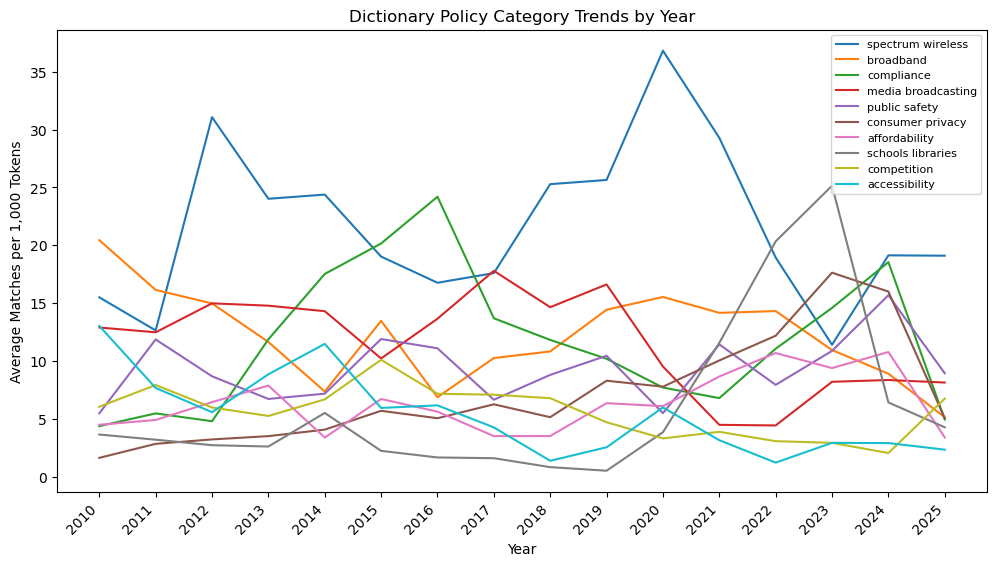

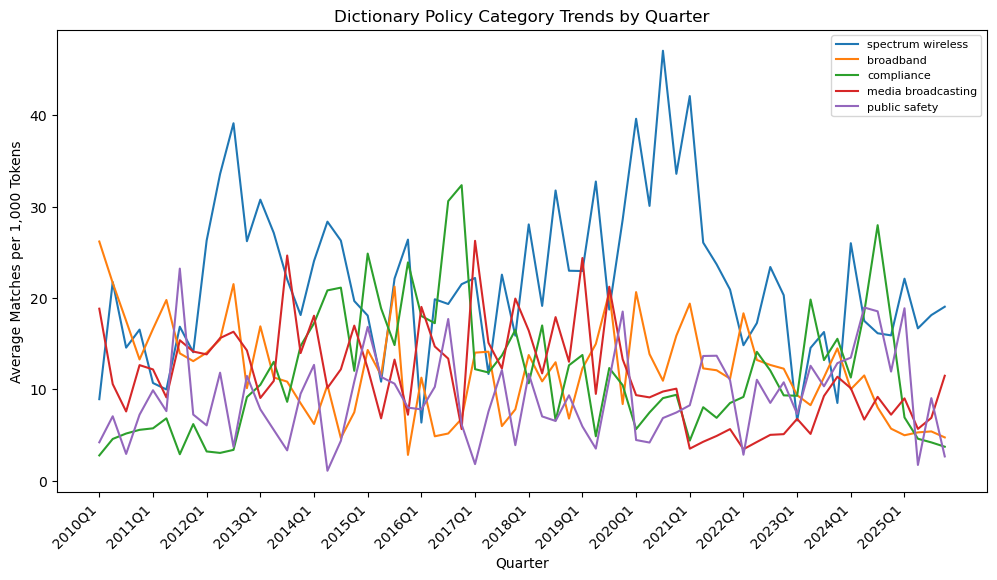

In [67]:
policy_trend_rate_cols = [f"{category}_avg_rate_per_1000_tokens" for category in policy_categories]

plot_lines(
    dictionary_policy_trend_by_year,
    "year",
    policy_trend_rate_cols,
    "Dictionary Policy Category Trends by Year",
    "Average Matches per 1,000 Tokens",
    top_n=10
)

plot_lines(
    dictionary_policy_trend_by_quarter,
    "quarter",
    policy_trend_rate_cols,
    "Dictionary Policy Category Trends by Quarter",
    "Average Matches per 1,000 Tokens",
    top_n=5,
    tick_every=4,
)